# Identification of volatility regimes by clustering on a transformer latent space

Data sets : <br>
Historical data from 2000-01-01 to 2025-01-01 of <br>
S&P 500 (^GSPC) and CBOE Volatility Index (^VIX)

The reconstructive transformer model here does not learn a persistent, generalized regime mapping. <br>
Its latent space is local and has to be retrained for new data. Clustering has to be re-run on the new <br>
latent space. <br>

LESSONS LEARNED:
- k-means is too inflexible for this task. Assumes spherical clusters with equal variance <br> in all directions (Euclidean distance). Can't properly deal with non-uniform clusters. <br> Hard assignments inferior to probabilistic assigments (GMM) in this scenario.

TODO:
- Out-of-sample evaluation  ( -> silhouette score )
- Further examine latent space
- Generate synthetic vola sequences : <br>
  -- Fit GMM to latent space <br>
  -- sample z ~ GMM <br>
  -- decode(z) = synth data, needs to be transformed back to returns <br>
  -- Conditional VAE better suited ? (latent space follows a known prior)

In [ ]:
%pip install yfinance --quiet

In [ ]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

import yfinance as yf


# Latent space analysis

#import tensorflow as tf
#import tensorflow_probability as tfp
#tfd = tfp.distributions

In [ ]:
# ---------------
# Configuration
# ---------------

start_date = "2000-01-01"
end_date = "2025-01-01"
tickers = ["^GSPC", "^VIX"]

window_size = 30  # Sequence length (e.g., 30 trading days for one segment)
stride = 1        # sliding window step

batch_size = 64
latent_dim = 64  # Output dimension of the Transformer Encoder

num_clusters = 3 # Number of volatility regimes to find

In [ ]:
# ---------------------------------
# Data download and preprocessing
# ---------------------------------

data = yf.download(tickers, start=start_date, end=end_date,
                   progress=False, auto_adjust=False)["Adj Close"]
data = data.dropna()

# Compute log-returns
returns = np.log(data / data.shift(1)).dropna()

# Optionally use VIX as an extra feature
# Align returns of SP500 + VIX returns. Could also use raw VIX level.
df = returns.copy()

# Build windows
windows = []
for i in range(0, len(df) - window_size + 1, stride):
    window = df.iloc[i : i + window_size].values  # shape: (window_size,
                                                  #         num_features)
    windows.append(window)

windows = np.stack(windows)  # shape: (num_windows, window_size, num_features)
print("Windows shape:", windows.shape)

# Scale features (fit scaler on flattened windows)
nsamples, w, nfeat = windows.shape
scaler = StandardScaler()
windows_reshaped = windows.reshape(-1, nfeat)
windows_scaled = scaler.fit_transform(windows_reshaped).reshape(nsamples,
                                                                w, nfeat)


Windows shape: (6259, 30, 2)


In [ ]:
# ---------------------------------
# Inspect data
# ---------------------------------

print(data.tail(10))
#print(returns.tail(10))

#print(windows[1])
#print(windows_scaled[1])


Ticker            ^GSPC       ^VIX
Date                              
2024-12-17  6050.609863  15.870000
2024-12-18  5872.160156  27.620001
2024-12-19  5867.080078  24.090000
2024-12-20  5930.850098  18.360001
2024-12-23  5974.069824  16.780001
2024-12-24  6040.040039  14.270000
2024-12-26  6037.589844  14.730000
2024-12-27  5970.839844  15.950000
2024-12-30  5906.939941  17.400000
2024-12-31  5881.629883  17.350000


In [ ]:
# -------------------------------
# PyTorch Dataset + DataLoader
# -------------------------------

class TimeSeriesWindowDataset(Dataset):
    def __init__(
        self,
        windows: torch.Tensor
    ) -> None:
        # windows: numpy array of shape (num_windows, window_size, n_features)
        self.windows = torch.tensor(windows, dtype=torch.float32)

    def __len__(self) -> int:
        return self.windows.shape[0]

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.windows[idx]

dataset = TimeSeriesWindowDataset(windows_scaled)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
# Shuffling here is unproblematic since the temporal order inside a window
# is not affected.
# For out-of-sampling evaluation, shuffling has to be deactivated.


In [ ]:
# ---------------------------
# Transformer Encoder Model
# ---------------------------

class PositionalEncoding(nn.Module):
    def __init__(
        self,
        d_model: int,
        max_len: int = 5000
    ) -> None:
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2,
                         dtype=torch.float32) * (-np.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # shape (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

class TransformerEncoderModel(nn.Module):
    def __init__(
        self,
        input_dim: int,
        d_model: int = 64,
        num_heads: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        # project input to d_model
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,  # PyTorch ≥1.9
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,
                                                         num_layers=num_layers)
        # final pooling to produce a latent embedding
        self.pool = nn.AdaptiveAvgPool1d(1)  # will pool over sequence dimension
        self.latent_proj = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (batch, seq_len, input_dim)"""
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)  # (batch, seq_len, d_model)
        # transpose for pooling: (batch, d_model, seq_len)
        x_t = x.transpose(1, 2)
        pooled = self.pool(x_t).squeeze(-1)  # (batch, d_model)
        latent = self.latent_proj(pooled)
        return latent

# Instantiate model
input_dim = windows_scaled.shape[2]
model = TransformerEncoderModel(input_dim=input_dim, d_model=latent_dim,
                                num_heads=4, num_layers=2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
#print(model)

In [ ]:
# ------------------------------------------------------------
# Train Encoder (Optional Pre‑training / Self‑Supervised)
# ------------------------------------------------------------

# For simplicity, we train the encoder with a reconstruction objective
# (i.e., autoencoding), but could also use contrastive or predictive loss.
# We use a simple linear decoder.

class TransformerAutoencoder(nn.Module):
    def __init__(
        self,
        encoder: TransformerEncoderModel,
        seq_len: int,
        input_dim: int
    ) -> None:
        super().__init__()
        self.encoder = encoder
        self.seq_len = seq_len
        self.input_dim = input_dim

        # Decoder: project latent back to sequence
        self.latent_to_seq = nn.Linear(encoder.latent_proj.out_features,
                                       seq_len * input_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        latent = self.encoder(x)
        recon = self.latent_to_seq(latent)
        recon = recon.view(x.size(0), self.seq_len, self.input_dim)
        return recon, latent

ae = TransformerAutoencoder(model, seq_len=window_size,
                            input_dim=input_dim).to(device)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 50
for epoch in range(n_epochs):
    ae.train()
    total_loss = 0.0
    for batch in dataloader:
        batch = batch.to(device)
        recon, _ = ae(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.size(0)
    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}/{n_epochs}, Loss = {avg_loss:.6f}")


In [ ]:
# -------------------
# Embed All Windows
# -------------------

# Switch to eval
ae.eval()
latents = []
with torch.no_grad():
    for batch in DataLoader(dataset, batch_size=128):
        batch = batch.to(device)
        _, latent = ae(batch)
        latents.append(latent.cpu().numpy())
latents = np.vstack(latents)  # shape: (num_windows, latent_dim)

print("Latents shape:", latents.shape)

Latents shape: (6259, 64)


In [ ]:
# --------------
# Clustering
# --------------

# Clustering: GMM
gmm = GaussianMixture(n_components=num_clusters, covariance_type="full",
                      random_state=0)
gmm_labels = gmm.fit_predict(latents)

# Clustering: K-Means
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans_labels = kmeans.fit_predict(latents)


            count      mean       std       min       25%       50%       75%  \
gmm_label                                                                       
0          2313.0  0.012936  0.004078  0.003831  0.009778  0.013085  0.015646   
1           314.0  0.028742  0.012980  0.004487  0.020233  0.026220  0.040691   
2          3632.0  0.007236  0.002161  0.002245  0.005716  0.006896  0.008592   

                max  
gmm_label            
0          0.026972  
1          0.054091  
2          0.015781  




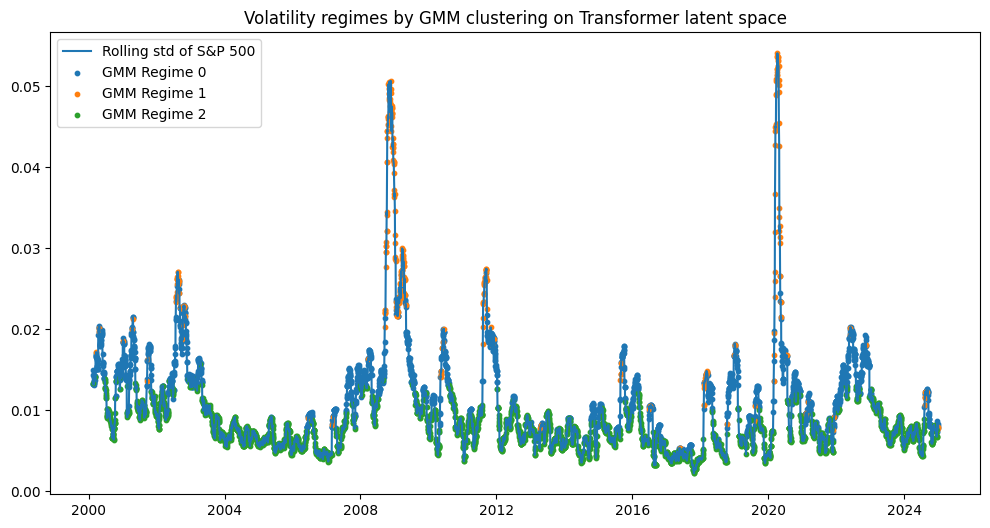



               count      mean       std       min       25%       50%  \
kmeans_label                                                             
0             1785.0  0.010658  0.006334  0.002771  0.006611  0.009010   
1             1533.0  0.011646  0.007716  0.002687  0.007054  0.009607   
2             2941.0  0.009640  0.005773  0.002245  0.006127  0.007883   

                   75%       max  
kmeans_label                      
0             0.013129  0.053634  
1             0.013909  0.054091  
2             0.011519  0.052538  




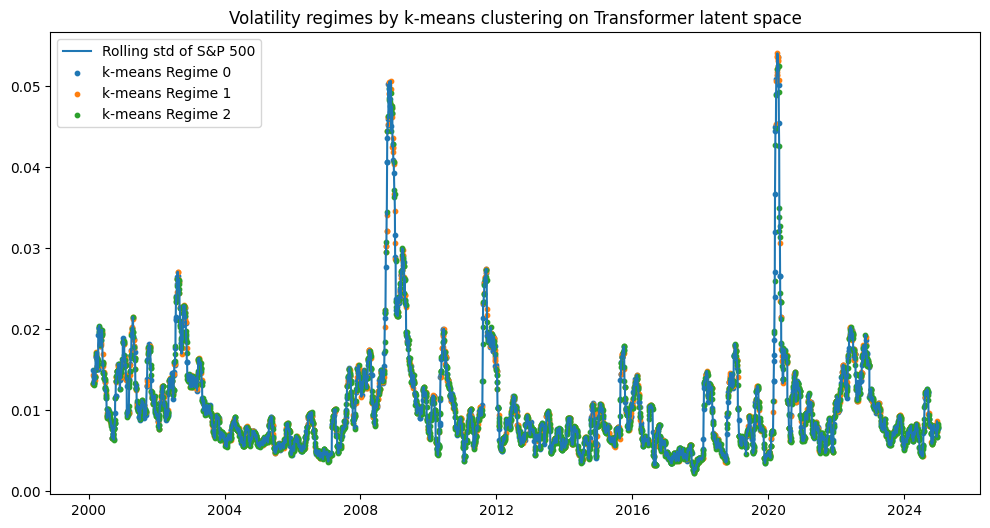

In [ ]:
# -----------------
# Analyze Regimes
# -----------------

# Map cluster labels back to time.
# Since we used sliding windows with stride = 1, the cluster assignment
# corresponds roughly to the start (or center) of each window.

dates = df.index[window_size - 1 :]  # aligning windows to end of each window
regime_df = pd.DataFrame({
    "date": dates,
    "gmm_label": gmm_labels,
    "kmeans_label": kmeans_labels,
})
regime_df = regime_df.set_index("date")

# Examine volatility (std of returns) per regime
vol = df["^GSPC"].rolling(window=window_size).std().iloc[window_size - 1 :]
regime_df["rolling_std"] = vol.values

print(regime_df.groupby("gmm_label")["rolling_std"].describe())
print("\n")

plt.figure(figsize=(12, 6))
plt.plot(regime_df.index, regime_df["rolling_std"],
         label="Rolling std of S&P 500")
for label in np.unique(gmm_labels):
    mask = regime_df["gmm_label"] == label
    plt.scatter(regime_df.index[mask], regime_df["rolling_std"][mask],
                label=f"GMM Regime {label}", s=10)
plt.legend()
plt.title("Volatility regimes by GMM clustering on Transformer latent space")
plt.show()

print("\n")
print(regime_df.groupby("kmeans_label")["rolling_std"].describe())
print("\n")
plt.figure(figsize=(12, 6))
plt.plot(regime_df.index, regime_df["rolling_std"],
         label="Rolling std of S&P 500")
for label in np.unique(kmeans_labels):
    mask = regime_df["kmeans_label"] == label
    plt.scatter(regime_df.index[mask], regime_df["rolling_std"][mask],
                label=f"k-means Regime {label}", s=10)
plt.legend()
plt.title("Volatility regimes by k-means clustering on Transformer latent space")
plt.show()